# c17 Multi-Label Fault Prediction — Improved BiLSTM



In [1]:
import sys, platform, subprocess, time

# RAM/CPU (psutil is usually available on Colab; fallback if not)
try:
    import psutil
    ram_gb = psutil.virtual_memory().total / 1e9
    cpu_logical = psutil.cpu_count(logical=True)
except Exception:
    ram_gb = None
    cpu_logical = None

print("=== Environment ===")
print("Python:", sys.version.replace("\n"," "))
print("Platform:", platform.platform())
print("CPU logical cores:", cpu_logical)
print("RAM (GB):", None if ram_gb is None else round(ram_gb, 2))

# PyTorch + GPU info
try:
    import torch
    print("\n=== PyTorch ===")
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print("VRAM (GB):", round(vram, 2))
except Exception as e:
    print("\nPyTorch not available or failed to import:", e)

# nvidia-smi (works as a shell command; safest is subprocess)
print("\n=== nvidia-smi ===")
try:
    out = subprocess.check_output(["nvidia-smi"], text=True)
    print(out.splitlines()[0])  # first line is enough as a quick check
except Exception as e:
    print("nvidia-smi not available:", e)


=== Environment ===
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CPU logical cores: 12
RAM (GB): 89.63

=== PyTorch ===
torch: 2.11.0+cu128
cuda available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM (GB): 42.41

=== nvidia-smi ===
Thu Jul 23 03:27:18 2026       


In [2]:
# ===== Step 2 Helpers: Timing + Peak RAM/VRAM =====
import os, time, threading, subprocess

# ---- CPU RAM (RSS) via psutil ----
try:
    import psutil
    _ps_proc = psutil.Process(os.getpid())
except Exception:
    psutil = None
    _ps_proc = None

def rss_mb():
    """Resident Set Size (process memory) in MB."""
    if _ps_proc is None:
        return None
    return _ps_proc.memory_info().rss / (1024**2)

# ---- GPU VRAM via nvidia-smi ----
def gpu_vram_mb():
    """Used VRAM on GPU0 in MB (Colab GPU runtimes)."""
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
            text=True
        )
        return float(out.strip().splitlines()[0])  # GPU0
    except Exception:
        return None

class PeakMonitor:
    """Background sampler for peak CPU RSS and GPU VRAM during a code region."""
    def __init__(self, interval_sec=0.5):
        self.interval = interval_sec
        self._stop = False
        self.peak_rss = 0.0
        self.peak_vram = 0.0
        self._thread = None

    def _run(self):
        while not self._stop:
            r = rss_mb()
            if r is not None:
                self.peak_rss = max(self.peak_rss, float(r))
            v = gpu_vram_mb()
            if v is not None:
                self.peak_vram = max(self.peak_vram, float(v))
            time.sleep(self.interval)

    def start(self):
        self._stop = False
        self.peak_rss = 0.0
        self.peak_vram = 0.0
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop = True
        if self._thread is not None:
            self._thread.join(timeout=2)
        return self.peak_rss, self.peak_vram


In [3]:
import itertools
from collections import defaultdict
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
test_path = '/content/drive/My Drive/circuits/c17.test'

In [6]:
# ------------------ Config ------------------
BITS_PER_STEP = 7        # ALL 7 bits in one timestep (seq_len = 1) -- key change #1
HIDDEN_SIZE   = 256
DROPOUT       = 0.0      # 64 training rows; dropout drove the original to collapse
LR            = 3e-3
EPOCHS        = 1200     # c17 is 64 training rows; each epoch is milliseconds
BATCH_SIZE    = 64
THRESHOLD     = 0.5      # sigmoid decision threshold for multi-label prediction


In [7]:
# ------------------ Reproducibility ------------------
import itertools, random
import numpy as np, torch
import torch.nn as nn, torch.optim as optim
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------ Expand Don't Care (unchanged) ------------------
def expand_dont_care(pattern):
    chars = [(c if c in '01' else ['0', '1']) for c in pattern]
    chars = [(c if isinstance(c, list) else [c]) for c in chars]
    return [''.join(bits) for bits in itertools.product(*chars)]

# ------------------ Parse .test File (unchanged) ------------------
def parse_isc_file(filepath):
    combo_to_faults = defaultdict(set)
    fault_to_combos = defaultdict(list)
    current_fault = None
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
            if not line or line.startswith("*"): continue
            if '/' in line:
                parts = line.split("/")
                current_fault = parts[0].strip().replace("->", "_") + "/" + parts[1].strip()
            elif ':' in line and current_fault:
                parts = line.split(":")[1].strip().split()
                input_pattern = parts[0]
                output_pattern = parts[1] if len(parts) > 1 else ""
                for xi in expand_dont_care(input_pattern):
                    for yo in expand_dont_care(output_pattern):
                        combined = xi + yo
                        combo_to_faults[combined].add(current_fault)
                        fault_to_combos[current_fault].append(combined)
    return combo_to_faults, fault_to_combos

# ------------------ Dataset Builder (unchanged) ------------------
def build_multilabel_dataset(combo_to_faults):
    all_faults = sorted({f for faults in combo_to_faults.values() for f in faults})
    fault_index = {fault: idx for idx, fault in enumerate(all_faults)}
    dataset = []
    for combo, faults in combo_to_faults.items():
        label_vector = [0] * len(all_faults)
        for fault in faults: label_vector[fault_index[fault]] = 1
        dataset.append(([int(bit) for bit in combo], label_vector))
    return dataset, fault_index


In [8]:
# ------------------ PyTorch Dataset ------------------
class FaultDataset(Dataset):
    """CHANGE #1: reshape to [seq_len, BITS_PER_STEP] instead of [seq_len, 1].
    With BITS_PER_STEP=7 the whole c17 pattern is a single timestep."""
    def __init__(self, data, bits_per_step=1):
        self.samples = data; self.k = bits_per_step
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        features, labels = self.samples[idx]
        x = torch.tensor(features, dtype=torch.float32).view(-1, self.k)
        return x, torch.tensor(labels, dtype=torch.float32)


In [9]:
# ------------------ LSTM Model ------------------
class FaultLSTM(nn.Module):
    """CHANGE #2: bidirectional with the corrected readout (both directions of the last
    layer concatenated). CHANGE #3: returns LOGITS -- pair with BCEWithLogitsLoss."""
    def __init__(self, input_size, hidden_size, output_size, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True,
                            num_layers=2, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, output_size)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        h = torch.cat([hn[-2], hn[-1]], dim=1)     # last layer, both directions
        return self.fc(h)                          # logits (no sigmoid here)


In [10]:
# ===== Step 2: Dataset Build Timing/Memory =====
data_monitor = PeakMonitor(interval_sec=0.5)
t_data0 = time.time(); data_monitor.start()

combo_to_faults, fault_to_combos = parse_isc_file(test_path)
dataset, fault_index = build_multilabel_dataset(combo_to_faults)

train_data, val_data = train_test_split(dataset, test_size=0.2, random_state=SEED)
train_dataset = FaultDataset(train_data, BITS_PER_STEP)
val_dataset   = FaultDataset(val_data,   BITS_PER_STEP)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64)

output_size = len(fault_index)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FaultLSTM(BITS_PER_STEP, HIDDEN_SIZE, output_size, dropout=DROPOUT).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

avg_faults = np.mean([sum(l) for _, l in dataset])
zeros_baseline = 1.0 - avg_faults / output_size
print("\n=== Dataset summary (c17 / multi-label) ===")
print(f"  Unique patterns   : {len(dataset)}   (train {len(train_data)} / val {len(val_data)})")
print(f"  Fault labels      : {output_size}")
print(f"  Avg faults/pattern: {avg_faults:.2f}")
print(f"  Sequence length   : {len(train_data[0][0]) // BITS_PER_STEP}  (BITS_PER_STEP={BITS_PER_STEP})")
print(f"  ALL-ZEROS BASELINE: {zeros_baseline:.4f}  <-- element-wise accuracy below this is meaningless")
print(f"  Model params      : {sum(p.numel() for p in model.parameters()):,}  | device: {device}")

peak_rss_data, peak_vram_data = data_monitor.stop(); t_data1 = time.time()
print(f"\nDataset build wall time: {t_data1 - t_data0:.2f} s")
print(f"Peak CPU RSS: {peak_rss_data:.1f} MB" if peak_rss_data > 0 else "Peak CPU RSS: N/A")
print(f"Peak GPU VRAM: {peak_vram_data:.0f} MB" if peak_vram_data > 0 else "Peak GPU VRAM: N/A")



=== Dataset summary (c17 / multi-label) ===
  Unique patterns   : 80   (train 64 / val 16)
  Fault labels      : 22
  Avg faults/pattern: 3.75
  Sequence length   : 1  (BITS_PER_STEP=7)
  ALL-ZEROS BASELINE: 0.8295  <-- element-wise accuracy below this is meaningless
  Model params      : 2,130,966  | device: cuda

Dataset build wall time: 10.60 s
Peak CPU RSS: 1000.5 MB
Peak GPU VRAM: 534 MB


In [11]:
# ===== Step 2: Train+Eval Timing/Memory =====
train_monitor = PeakMonitor(interval_sec=0.5)
t_train0 = time.time(); train_monitor.start()

train_losses, val_losses, val_f1s, val_accuracies, val_exact = [], [], [], [], []

for epoch in range(EPOCHS):
    model.train(); total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad(); loss = criterion(model(X), y)
        loss.backward(); optimizer.step(); total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval(); y_true, y_pred = [], []; val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X); val_loss += criterion(out, y).item()
            y_true.append(y.cpu().numpy())
            y_pred.append((torch.sigmoid(out).cpu().numpy() > THRESHOLD).astype(int))
    val_losses.append(val_loss / len(val_loader))
    y_true = np.concatenate(y_true, axis=0); y_pred = np.concatenate(y_pred, axis=0)

    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc = (y_true == y_pred).sum() / y_true.size
    exact = (y_true == y_pred).all(axis=1).mean()
    val_f1s.append(f1); val_accuracies.append(acc); val_exact.append(exact)

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:4d} | TL: {train_losses[-1]:.4f} | VL: {val_losses[-1]:.4f} | "
              f"Elem: {acc:.4f} | Exact: {exact:.4f} | MacroF1: {f1:.4f}")

# ------------------ Final Evaluation ------------------
stuck_at_0_indices = [idx for fault, idx in fault_index.items() if fault.endswith('/0')]
stuck_at_1_indices = [idx for fault, idx in fault_index.items() if fault.endswith('/1')]

def type_accuracy(y_true, y_pred, indices, fault_type):
    yt, yp = y_true[:, indices], y_pred[:, indices]
    correct, total = (yt == yp).sum(), yt.size
    print(f"{fault_type} Accuracy: {correct/total:.4f} ({correct}/{total})")

n_pos_pred, n_pos_true = int(y_pred.sum()), int(y_true.sum())
print(f"\n--- COLLAPSE GUARD ---")
print(f"Predicted positives: {n_pos_pred}  |  true positives: {n_pos_true}")
if n_pos_pred == 0:
    print("*** MODEL COLLAPSED to all-negative: element-wise accuracy is meaningless here. ***")

print(f"\nFinal Macro F1        : {val_f1s[-1]:.4f}")
print(f"Final Micro F1        : {f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
print(f"Final Element-wise Acc: {val_accuracies[-1]:.4f}   (all-zeros baseline {zeros_baseline:.4f})")
print(f"Final Exact-match Acc : {val_exact[-1]:.4f}   (entire fault set correct)")
print("\n--- Fault-Type Accuracy ---")
type_accuracy(y_true, y_pred, stuck_at_0_indices, "Stuck-at-0")
type_accuracy(y_true, y_pred, stuck_at_1_indices, "Stuck-at-1")

peak_rss_train, peak_vram_train = train_monitor.stop(); t_train1 = time.time()
print("\n=== Train+Eval Summary (c17 / LSTM) ===")
print(f"Train+eval wall time: {t_train1 - t_train0:.2f} s")
print(f"Peak CPU RSS: {peak_rss_train:.1f} MB" if peak_rss_train > 0 else "Peak CPU RSS: N/A")
print(f"Peak GPU VRAM: {peak_vram_train:.0f} MB" if peak_vram_train > 0 else "Peak GPU VRAM: N/A")


Epoch    0 | TL: 0.6955 | VL: 0.6836 | Elem: 0.8011 | Exact: 0.0000 | MacroF1: 0.0828
Epoch   50 | TL: 0.2070 | VL: 0.2825 | Elem: 0.8864 | Exact: 0.0625 | MacroF1: 0.2867
Epoch  100 | TL: 0.0255 | VL: 0.1235 | Elem: 0.9545 | Exact: 0.5000 | MacroF1: 0.8064
Epoch  150 | TL: 0.0039 | VL: 0.1109 | Elem: 0.9602 | Exact: 0.5000 | MacroF1: 0.8129
Epoch  200 | TL: 0.0018 | VL: 0.1109 | Elem: 0.9602 | Exact: 0.5000 | MacroF1: 0.8129
Epoch  250 | TL: 0.0011 | VL: 0.1106 | Elem: 0.9631 | Exact: 0.5625 | MacroF1: 0.8205
Epoch  300 | TL: 0.0007 | VL: 0.1104 | Elem: 0.9631 | Exact: 0.5625 | MacroF1: 0.8205
Epoch  350 | TL: 0.0006 | VL: 0.1100 | Elem: 0.9659 | Exact: 0.6250 | MacroF1: 0.8357
Epoch  400 | TL: 0.0004 | VL: 0.1097 | Elem: 0.9659 | Exact: 0.6250 | MacroF1: 0.8357
Epoch  450 | TL: 0.0003 | VL: 0.1095 | Elem: 0.9659 | Exact: 0.6250 | MacroF1: 0.8357
Epoch  500 | TL: 0.0003 | VL: 0.1092 | Elem: 0.9659 | Exact: 0.6250 | MacroF1: 0.8357
Epoch  550 | TL: 0.0002 | VL: 0.1090 | Elem: 0.9688 | 

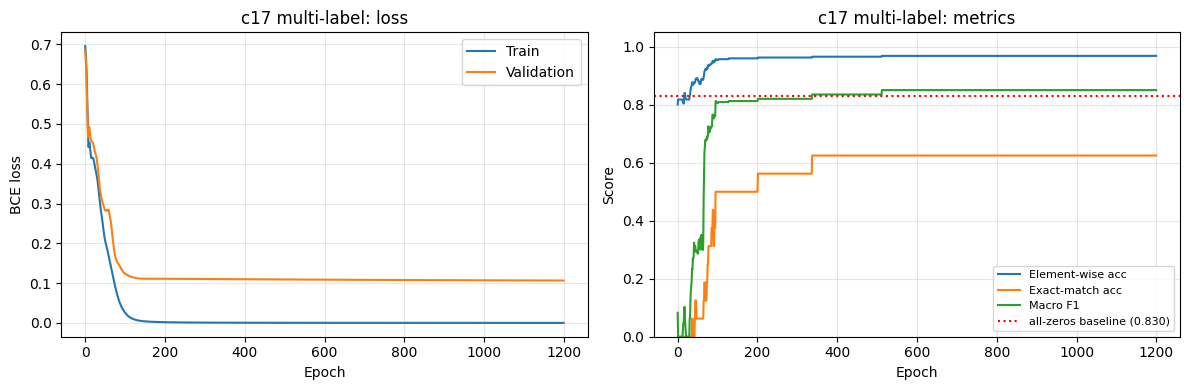

In [12]:
# ------------------ Plotting ------------------
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train'); axes[0].plot(val_losses, label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss'); axes[0].legend()
axes[0].set_title('c17 multi-label: loss'); axes[0].grid(alpha=0.3)
axes[1].plot(val_accuracies, label='Element-wise acc')
axes[1].plot(val_exact, label='Exact-match acc')
axes[1].plot(val_f1s, label='Macro F1')
axes[1].axhline(zeros_baseline, color='red', ls=':', label=f'all-zeros baseline ({zeros_baseline:.3f})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score'); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8); axes[1].set_title('c17 multi-label: metrics'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
